In [2]:
import warnings 
import numpy as np
from numpy.linalg import LinAlgError
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx 
from networkx.drawing.nx_agraph import graphviz_layout
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import logit
from scipy import stats
from glob import glob 

warnings.filterwarnings('ignore')
%matplotlib inline
%load_ext autoreload
%autoreload 2

pd.options.display.float_format = "{:,.3f}".format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/dpclust_ccf'
INDIR_CONIPHER = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/conipher_trees'
INFILE_SHEET = '/home/grace/work/PPCG_DifferentialGenesetMutation/samplesheet.angel.alldonors.tsv'

INFILE_MUTATIONS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/manual/mutations.assigned.160326.tsv'
# INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/outputs/angel_mutations_all_donors/variant_processing/genesets.tsv'
# INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/genesets/h.all.v2026.1.Hs.symbols.tsv'
INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/genesets/c2.cp.kegg_medicus.v2026.1.Hs.symbols.tsv'
# INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/genesets/c4.cm.v2026.1.Hs.symbols.tsv'
# INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/genesets/c5.go.bp.v2026.1.Hs.symbols.tsv'
# INFILE_GENESETS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/genesets/c2.cp.reactome.v2026.1.Hs.symbols.tsv'
INFILE_SIZES = '/home/grace/work/PPCG_DifferentialGenesetMutation/outputs/angel_mutations_all_donors/variant_processing/sizes.tsv'
INFILE_HGNC = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/supporting/hgnc/hgnc_complete_set.txt'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Loading Data 
---

In [3]:
def load_hframe(filepath: str) -> pd.DataFrame:
    sheet = pd.read_csv(filepath, sep='\t', header=0)
    sheet['tissue'] = sheet['tissue'].replace('Recurrence', 'Metastasis')
    sheet = sheet.sort_values('sample')

    # annotating which files are present
    vclasses = ['SNV', 'INDEL', 'CNA', 'SV']
    sheet['Files'] = sheet['Missing_Files'].apply(format_files)
    for vclass in vclasses:
        sheet[vclass] = sheet['Files'].apply(lambda x: vclass in x)
    sheet = sheet.drop(['Files'], axis=1)

    data = []
    cohort_LUT = sheet.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
    for vclass in vclasses:
        for donor in sheet['donor'].unique():
            label = f"{donor}|{vclass}"
            cohort = cohort_LUT[donor]
            temp = sheet[(sheet['donor']==donor) & (sheet[vclass]==True)]
            primary = temp[temp['tissue']=='Primary']['sample'].nunique()
            secondary = temp[temp['tissue']=='Metastasis']['sample'].nunique()
            data.append((label, donor, vclass, cohort, primary, secondary))
    hframe = pd.DataFrame(data, columns=['label', 'donor', 'vclass', 'cohort', 'primary', 'secondary'])
    hframe['handling'] = hframe.apply(get_handling, axis=1)
    return hframe

def format_files(missing_text: str) -> set[str]:
    expected = set(['SNV', 'INDEL', 'CNA', 'SV'])
    if missing_text == '.':
        return expected
    missing = set(missing_text.split(','))
    return expected-missing

def get_handling(row: pd.Series) -> str:
    if row['primary'] == 0 and row['secondary'] == 0:
        return 'ignore'
    elif row['primary'] == 1 and row['secondary'] == 0:
        return 'single_primary'
    elif row['primary'] >= 2 and row['secondary'] == 0:
        return 'multi_primary'
    elif row['primary'] == 0 and row['secondary'] == 1:
        return 'single_met'
    elif row['primary'] == 0 and row['secondary'] >= 2:
        return 'multi_met'
    elif row['primary'] == 1 and row['secondary'] == 1:
        return 'single_primary_single_met'
    elif row['primary'] == 1 and row['secondary'] >= 2:
        return 'single_primary_multi_met'
    raise NotImplementedError(row)

# test run
hframe = load_hframe(INFILE_SHEET)
hframe.head()

,label,donor,vclass,cohort,primary,secondary,handling
0,PPCG0001|SNV,PPCG0001,SNV,PPCG,1,0,single_primary
1,PPCG0002|SNV,PPCG0002,SNV,PPCG,1,0,single_primary
2,PPCG0003|SNV,PPCG0003,SNV,PPCG,1,0,single_primary
3,PPCG0004|SNV,PPCG0004,SNV,PPCG,1,0,single_primary
4,PPCG0005|SNV,PPCG0005,SNV,PPCG,1,0,single_primary


In [4]:
def annotate_assignment_verdict_dynamic(table: pd.DataFrame, hframe: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    dpc_weird_donors = set(['PPCG0388', 'PPCG0395', 'PPCG0425', 'PPCG0427', 'PPCG0428', 'PPCG0434', 'PPCG0442', 'PPCG1062', 'PPCG1072'])
    
    df = table.copy()
    handling_LUT = hframe.set_index('label')['handling'].to_dict()
    df['label'] = df['donor'] + '|' + df['vclass']
    df['handling'] = df['label'].map(handling_LUT)
    assert df['handling'].isna().sum() == 0

    mask0 = df['cohort']=='COMBI'
    mask1 = df['handling']=='single_primary_multi_met'
    mask2 = df['donor'].isin(dpc_weird_donors)
    
    mask_dpc = mask0 & mask1 & ~mask2
    mask_var = ~mask0 | ~mask1 | mask2 

    df.loc[mask_dpc, 'asmt'] = df.loc[mask_dpc, 'DPC_origin'] + ':' + df.loc[mask_dpc, 'DPC_ctype']
    df.loc[mask_var, 'asmt'] = df.loc[mask_var, 'var_origin'] + ':' + df.loc[mask_var, 'var_ctype']
    
    df.loc[mask_dpc, 'asmt_src'] = 'DPC'
    df.loc[mask_var, 'asmt_src'] = 'VAR'
    
    df = df.drop(['label', 'handling'], axis=1)
    assert df['asmt'].isna().sum() == 0
    assert df['asmt_src'].isna().sum() == 0
    return df.copy()

def annotate_assignment_verdict_var(table: pd.DataFrame, hframe: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    df = table.copy()
    df['asmt'] = df['var_origin'] + ':' + df['var_ctype']
    df['asmt_src'] = 'VAR'
    assert df['asmt'].isna().sum() == 0
    assert df['asmt_src'].isna().sum() == 0
    return df.copy()


In [16]:
def load_data(mutations_path: str, samplesheet_path: str) -> pd.DataFrame:
    df = pd.read_csv(mutations_path, sep='\t', header=0)
    df['donor'] = df['sample'].apply(lambda x: x[:8])
    hframe = load_hframe(samplesheet_path)
    df = annotate_assignment_verdict_var(df, hframe)
    return df 

table = load_data(INFILE_MUTATIONS, INFILE_SHEET)
table.head()

,ID,cohort,sample,tissue,gene,coords,ref,alt,vclass,vtype,annotation,var_ccf,var_origin,var_ctype,DPC_clone,DPC_ccf,DPC_origin,DPC_ctype,donor,asmt,asmt_src
0,PPCG0001:0001,PPCG,PPCG0001a,Primary,NDST2,10:75562095,C,T,SNV,SNV,3_prime_UTR_variant,0.880,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
1,PPCG0001:0002,PPCG,PPCG0001a,Primary,ADK,10:76221633-10:115874382,.,.,SV,INV,transcript_ablation,NaN,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
2,PPCG0001:0003,PPCG,PPCG0001a,Primary,OR52A5,11:5153383,GCC,G,INDEL,INDEL,frameshift_variant,0.880,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
3,PPCG0001:0004,PPCG,PPCG0001a,Primary,DGCR8,11:65251003-22:20095850,.,.,SV,TRA,transcript_ablation,NaN,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
4,PPCG0001:0005,PPCG,PPCG0001a,Primary,EMSY,11:76174922,C,T,SNV,SNV,missense_variant,1.000,Primary,Trunk,NaN,NaN,NaN,NaN,PPCG0001,Primary:Trunk,VAR


----
## Filtering & Selection
----

***Donor Filtering***

In [76]:
def filter_ppcg_control(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    valid = ['PPCG0001', 'PPCG0003', 'PPCG0004', 'PPCG0006', 'PPCG0008', 'PPCG0010', 'PPCG0017', 'PPCG0019', 'PPCG0022', 'PPCG0052', 'PPCG0053', 'PPCG0074', 'PPCG0134', 'PPCG0138', 'PPCG0159', 'PPCG0161', 'PPCG0172', 'PPCG0174', 'PPCG0203', 'PPCG0261', 'PPCG0264', 'PPCG0275', 'PPCG0280', 'PPCG0283', 'PPCG0284', 'PPCG0289', 'PPCG0306', 'PPCG0307', 'PPCG0314', 'PPCG0342', 'PPCG0347', 'PPCG0348', 'PPCG0349', 'PPCG0408', 'PPCG0443', 'PPCG0452', 'PPCG0487', 'PPCG0516', 'PPCG0517', 'PPCG0519', 'PPCG0525', 'PPCG0548', 'PPCG0553', 'PPCG0567', 'PPCG0568', 'PPCG0592', 'PPCG0594', 'PPCG0595', 'PPCG0612', 'PPCG0615', 'PPCG0631', 'PPCG0640', 'PPCG0696', 'PPCG0775', 'PPCG0792', 'PPCG0805', 'PPCG0813', 'PPCG0830', 'PPCG0831', 'PPCG0837', 'PPCG0885', 'PPCG0889', 'PPCG0910', 'PPCG0963', 'PPCG0977']
    df = table.copy()
    before = set(df['donor'].unique())
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors not in the 65-donor control group')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")
    return df.copy()

def filter_donors_without_prostate(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    # filter donors without any mutations observed in their primary tissue sample
    df = table.copy()
    before = set(df['donor'].unique())
    valid = set(df[df['tissue']=='Primary']['donor'].unique())
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors without primary tissue')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")
    return df.copy()

def filter_donors_without_dpclust(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    df = table.copy()
    
    # filter donors without DPClust CCF file. 
    before = set(df['donor'].unique())
    donor2ccfpath = {x.split('/')[-1][:8]: x for x in glob(f"{INDIR_DPCLUST}/*_Cluster_CCFs.csv")}
    valid = set(donor2ccfpath.keys())
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors without DPClust')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")

    # filter donors missing a sample in their DPClust CCF file.
    before = after
    valid = set()
    for donor in df['donor'].unique():
        fields = pd.read_csv(donor2ccfpath[donor], sep=',', header=0).columns.to_list()
        dpc_samples = set([f[:9] for f in fields if f.startswith('PPCG')])
        mut_samples = set(df[df['donor']==donor]['sample'].unique())
        if len(mut_samples - dpc_samples) == 0:
            valid.add(donor)
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors where DPClust is missing a sample')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")
    
    # filter donors which don't have a DPClust 'Cluster_Type' marked 'Trunk'.
    before = after
    valid = set()
    for donor in df['donor'].unique():
        ccfs = pd.read_csv(donor2ccfpath[donor], sep=',', header=0)
        ctypes = set(ccfs['Cluster_Type'].unique())
        if 'Trunk' in ctypes:
            valid.add(donor)
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors where DPClust has no truncal cluster')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")

    return df.copy()

def filter_donors_without_trees(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    df = table.copy()
    before = set(df['donor'].unique())
    valid = set([x.split('/')[-2][:8] for x in glob(f"{INDIR_CONIPHER}/*/allTrees.txt")])
    df = df[df['donor'].isin(valid)]
    after = set(df['donor'].unique())
    if verbose:
        print('\nRemove donors without CONIPHER tree')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")
    return df.copy()

def filter_hypermutators(table: pd.DataFrame, max_mutated_genes: int=500, verbose: bool=False) -> pd.DataFrame:
    df = table.copy()

    blacklist = set()
    for vclass in ['SNV','INDEL','CNA','SV']:
        counts = df[df['vclass']==vclass].groupby('donor')['gene'].nunique()
        invalid = set(counts[counts>max_mutated_genes].index.to_list())
        blacklist.update(invalid)
    
    before = set(df['donor'].unique())
    df = df[~df['donor'].isin(blacklist)]
    after = set(df['donor'].unique())
    
    if verbose:
        print(f'\nRemove hypermutators (more than {max_mutated_genes} mutated genes)')
        print(len(after), f"(removed {', '.join(sorted(list(before-after)))})")
    
    return df.copy()

# test run
table = load_data(INFILE_MUTATIONS, INFILE_SHEET)
df = table[table['cohort']=='COMBI']
df = filter_donors_without_prostate(df)
df = filter_donors_without_dpclust(df)
df = filter_donors_without_trees(df)



***Mutation Filtering***

In [ ]:
# # proves that...
# # - donor|vclass (label) combinations marked 'single_primary_multi_met' should be filtered according to DPC_origin & DPC_ctype
# # - all other mutations should be filtered according to var_origin & var_ctype
# muts = pd.read_csv(INFILE_MUTATIONS, sep='\t', header=0)
# print(muts['tissue'].value_counts())
# muts['donor'] = muts['sample'].apply(lambda x: x[:8])
# muts['label'] = muts['donor'] + '|' + muts['vclass']

# muts = muts[muts['cohort']=='COMBI']
# muts = filter_donors_without_prostate(muts)
# muts = filter_donors_without_dpclust(muts)
# muts = filter_donors_without_trees(muts)

# hframe = load_hframe(INFILE_SHEET)
# hframe = hframe[hframe['donor'].isin(set(muts['donor'].unique()))]
# hframe = hframe.rename(columns={'primary': 'files_primary', 'secondary': 'files_secondary'})
# hframe = hframe.set_index('label')

# hframe['vars_primary'] = muts[muts['tissue']=='Primary'].groupby('label')['sample'].nunique()
# hframe['vars_primary'] = hframe['vars_primary'].fillna(0).astype(int)
# hframe['vars_secondary'] = muts[muts['tissue']=='Metastasis'].groupby('label')['sample'].nunique()
# hframe['vars_secondary'] = hframe['vars_secondary'].fillna(0).astype(int)

# print()
# print(hframe.groupby('handling')['donor'].nunique())

# hframe = hframe.sort_values(by=['files_primary', 'files_secondary'], ascending=[False, False])
# hframe[(hframe['files_primary']!=hframe['vars_primary']) | (hframe['files_secondary']!=hframe['vars_secondary'])]



In [22]:
def filter_seeding_trajectory(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    blacklist = ['Primary:Leaf', 'Metastasis:Leaf']

    df = table.copy()
    before = set(df['ID'].unique())
    df = df[~df['asmt'].isin(blacklist)]
    after = set(df['ID'].unique())
    if verbose:
        print('\nRemove primary/secondary leaf clones')
        print(len(after), f"(removed {len(before-after)} mutations)")

    return df.copy()

def filter_primary_leaves(table: pd.DataFrame, verbose: bool=False) -> pd.DataFrame:
    blacklist = ['Primary:Leaf']

    df = table.copy()
    before = set(df['ID'].unique())
    df = df[~df['asmt'].isin(blacklist)]
    after = set(df['ID'].unique())
    if verbose:
        print('\nRemove primary leaf clones')
        print(len(after), f"(removed {len(before-after)} mutations)")

    return df.copy()

# test run
table = load_data(INFILE_MUTATIONS, INFILE_SHEET)
df = table[table['cohort']=='COMBI']
df = filter_donors_without_prostate(df)
df = filter_donors_without_dpclust(df)
df = filter_donors_without_trees(df)
df = filter_seeding_trajectory(df, verbose=True)
df.head()


Remove primary/secondary leaf clones
11376 (removed 16090 mutations)


,ID,cohort,sample,tissue,gene,coords,ref,alt,vclass,vtype,annotation,var_ccf,var_origin,var_ctype,DPC_clone,DPC_ccf,DPC_origin,DPC_ctype,donor,asmt,asmt_src
14018,PPCG0086:0001,COMBI,PPCG0086a,Metastasis,HPSE2,10:97263968-10:100625858,.,.,SV,DUP,gene_fusion&frameshift_variant,NaN,Primary,Trunk,1.000,1.010,Primary,Trunk,PPCG0086,Primary:Trunk,VAR
14019,PPCG0086:0001,COMBI,PPCG0086c,Metastasis,HPSE2,10:97263968-10:100625858,.,.,SV,DUP,gene_fusion&frameshift_variant,NaN,Primary,Trunk,1.000,1.010,Primary,Trunk,PPCG0086,Primary:Trunk,VAR
14020,PPCG0086:0001,COMBI,PPCG0086d,Metastasis,HPSE2,10:97263968-10:100625858,.,.,SV,DUP,gene_fusion&frameshift_variant,NaN,Primary,Trunk,1.000,1.010,Primary,Trunk,PPCG0086,Primary:Trunk,VAR
14021,PPCG0086:0001,COMBI,PPCG0086a,Metastasis,HPSE2,10:100049199-10:100414182,.,.,SV,DUP,transcript_ablation,NaN,Primary,Trunk,1.000,1.010,Primary,Trunk,PPCG0086,Primary:Trunk,VAR
14022,PPCG0086:0001,COMBI,PPCG0086e,Primary,HPSE2,10:100049199-10:100414182,.,.,SV,DUP,transcript_ablation,NaN,Primary,Trunk,1.000,1.010,Primary,Trunk,PPCG0086,Primary:Trunk,VAR


----
## Single Genes
----

In [9]:
PPCG_DRIVERS = { 'TP53','SPOP','PTEN','CSMD3','FOXA1','LRP1B','MYO15A','KMT2A','COL1A2','MED12','PIK3CA','TBL1XR1','CDK12','KMT2D','ROBO2','CHD3','DOCK2','KMT2C','ZMYM3','ATM','CHD7','GNAS','MAP1B','RB1','PIK3C2G','APC','TAF1L','AR','ARID1A','CIC','KDM6A','MAP3K4','NLRP1','ZFHX3','ABCC6','ASXL2','CHD6','CTNNB1','NF1','TRPM2','CASZ1','CUL3','MGA','NRXN3','RAG1','RPTOR','SERPINF2','SMARCA1','ASH1L','CHD1','COL5A3','DLC1','DOCK10','IL6ST','NKX3-1','PIK3CB','ZNF292','ARID4B','BRAF','ETV3','JAK1','LCE2B','PTPN12','SF3B1','SLC4A2','TFIP11','VIL1','ADRA1A','BRPF1','CHRNB2','COL15A1','FOXP1','ITGB2','LIFR','LILRB4','MAMLD1','PRKCZ','PTPRC','TULP1','XPO1','BRCA2','CHUK','CNOT3','ERF','FES','IRF8','KRAS','NOX3','OPRL1','PALB2','PMS1','RPL11','SETD2','SMARCC2','SPATA18','ST3GAL4','TRPM4','ARID2','CDC27','CDKN1B','COL5A1','CRTC1','CYP2A6','ERG','GNB5','GPR176','GPR55','HRAS','IGF2R','IL22','JADE2','KLK8','MAGEA3','MATN4','MME','MYBBP1A','NCOR2','PDS5A','PTN','PTPN4','RAPGEF3','RNF43','ROBO1','RPRD2','SAMD9','SETDB1','STAB2','STXBP2','TBX3','UNC13D','USP28','AKT1','ANKRD54','ATG5','CASP8','CDH12','CYBA','CYP2B6','DTL','EIF5A','GRIN1','HLA-B','HLA-DOA','HLA-DQB2','HSPA9','HYAL2','IDH1','IL2RA','IL7','IRF4','ISG15','KEAP1','MAP2K6','MAP3K1','MAS1','MBD1','NCOR1','NUCKS1','PDE4D','PGLYRP2','PIK3R1','PIK3R2','PPP2R2A','PTPN9','RELA','S100A9','S1PR1','SLC2A4','SMAD2','SPEN','ST8SIA2','STAT5A','SULT1A2','TACR2','TAP1','TBC1D2','TXNIP','ZNF683','ADAM28','ADAMTS8','CDH1','DHX30','FOXO1','GRPR','HCAR2','IFNA7','IL10','ITSN1','ITSN2','LRRC8A','MAPK11','MET','NCOA7','NDST4','NR3C1','PPL','PSMB7','PSMD4','PTPN5','PYHIN1','RHOU','RPS6KA3','RYBP','SMAD4','USP7','ANTXR2','B2M','BIRC5','CHST10','EPHX1','FADD','HDAC8','IFNA16','MTUS1','NDST2','NPS','PAX6','RNF31','RPL22','SENP6','SMARCAD1','TMPRSS2','U2AF1','WASF3','ZBTB16' }

GUNDEM_DRIVERS = {
    'CDK12',
    'PTEN',
    'CDH1',
    'TP53',
    'SPOP',
    'DOCK2',
    'PIK3CA',
    'AR',
    'CDH11',
    'ZFHX3',
    'BRCA1',
    'CTNNB1',
    'CEBPA',
    'ARID1A',
    'BRCA2',
    'RB1',
    'SMAD4',
    'RUNX2',
    # 'MLL3',
    'TBL1XR1',
    'CDKN1B',
}

DRIVERS = PPCG_DRIVERS | GUNDEM_DRIVERS
print(len(DRIVERS))

229


In [78]:
def summarise_basic_info(df: pd.DataFrame, treat: str, control: str) -> None:
    print('\n--- Basic Info ---\n')
    print(f"Treatment group: {treat}")
    print(f"Control group:   {control}")
    print()
    sframe = pd.DataFrame(index=[treat, control])
    sframe['Donors'] = df.groupby('cohort')['donor'].nunique()
    sframe['Genes'] = df.groupby('cohort')['gene'].nunique()
    sframe['Variants'] = df.groupby('cohort')['ID'].nunique()
    print(sframe)

def summarise_donors(df: pd.DataFrame, treat: str, control: str) -> None:
    print('\n--- Donors ---')
    for clsmem in [treat, control]:
        print()
        print(f'[{clsmem}]')
        # dfslice = df[df['cohort']==clsmem].drop_duplicates('ID')
        dfslice = df[df['cohort']==clsmem].drop_duplicates(['donor', 'vclass', 'gene'])
        counts = dfslice.groupby('donor')['vclass'].value_counts().unstack().fillna(0).astype(int)
        counts['total'] = dfslice.groupby('donor')['gene'].nunique()
        counts = counts.sort_values('total', ascending=False)
        print(counts.head(10))

def summarise_vclasses(df: pd.DataFrame, treat: str, control: str) -> None:
    print('\n--- Variant Class ---')
    vclasses = sorted(list(df['vclass'].unique()))

    for clsmem in [treat, control]:
        print()
        print(f'[{clsmem}]')
        dfslice = df[df['cohort']==clsmem].drop_duplicates('ID')
        counts = pd.DataFrame(index=vclasses)
        counts['vars'] = dfslice['vclass'].value_counts()
        counts['genes'] = dfslice.groupby('vclass')['gene'].nunique()
        counts['donors'] = dfslice.groupby('vclass')['donor'].nunique()
        
        for vclass in vclasses:
            counts.loc[vclass, 'med. vars p/donor'] = round(dfslice[dfslice['vclass']==vclass]['donor'].value_counts().median(), 0)
        counts = counts.astype(int)
        print(counts)

def top_genes(df: pd.DataFrame, treat: str, control: str) -> None:
    print('\n--- Gene Summary (stratified by variant class) ---')
    for clsmem in [treat, control]:
        print()
        print(f'[{clsmem}]')
        dfslice = df[df['cohort']==clsmem]
        ndonors = dfslice['donor'].nunique()
        all_genes = sorted(list(dfslice['gene'].unique()))
        counts = pd.DataFrame(index=all_genes)
        counts['sv'] = dfslice[dfslice['vclass']=='SV'].groupby('gene')['donor'].nunique()
        counts['snvs'] = dfslice[dfslice['vclass']=='SNV'].groupby('gene')['donor'].nunique()
        counts['indels'] = dfslice[dfslice['vclass']=='INDEL'].groupby('gene')['donor'].nunique()
        counts['cna'] = dfslice[dfslice['vclass']=='CNA'].groupby('gene')['donor'].nunique()
        counts['total'] = dfslice.groupby('gene')['donor'].nunique()
        counts = counts.fillna(0).astype(int)
        counts['donors prop.'] = counts['total'] / ndonors
        counts['donors prop.'] = counts['donors prop.'].apply(lambda x: f"{x*100:.1f} %")
        counts = counts.sort_values(by='total', ascending=False)
        print(counts.head(20))

def plot_distribution(df: pd.DataFrame, treat: str, control: str) -> None:
    # for vclass in ['SNV','INDEL','CNA','SV']:
    # counts = df[df['vclass']==vclass].groupby('donor')['gene'].nunique().to_frame()
    counts = df.groupby('donor')['gene'].nunique().to_frame()
    counts['cohort'] = df.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
    counts = counts.reset_index()
    sns.histplot(counts, x='gene', hue='cohort', bins=10, multiple='dodge')
    # plt.title(vclass)
    plt.show()
    plt.close()


In [ ]:
print('loading hframe')
hframe = load_hframe(INFILE_SHEET)

print('loading mutations')
table = pd.read_csv(INFILE_MUTATIONS, sep='\t', header=0)
table['donor'] = table['sample'].apply(lambda x: x[:8])
table = annotate_assignment_verdict(table, hframe)

print('filtering PPCG donors/mutations')
df_ppcg = table[table['cohort']=='PPCG'].copy()
df_ppcg = filter_ppcg_control(df_ppcg)

print('filtering COMBI donors/mutations')
df_combi = table[table['cohort']=='COMBI'].copy()
df_combi = filter_donors_without_prostate(df_combi)
df_combi = filter_donors_without_dpclust(df_combi)
df_combi = filter_donors_without_trees(df_combi)
df_combi = filter_seeding_trajectory(df_combi, verbose=True)
# df_combi = filter_primary_leaves(df_combi, verbose=True)

table = pd.concat([df_ppcg, df_combi], ignore_index=True)
table = filter_hypermutators(table, max_mutated_genes=500)
assert table['asmt'].isna().sum() == 0
assert table['asmt_src'].isna().sum() == 0

summarise_basic_info(table, treat='COMBI', control='PPCG')
summarise_donors(table, treat='COMBI', control='PPCG')
# summarise_vclasses(table, treat='COMBI', control='PPCG')
# top_genes(table, treat='COMBI', control='PPCG')
table.head()

loading hframe
loading mutations
filtering PPCG donors/mutations
filtering COMBI donors/mutations

Remove primary/secondary leaf clones
11492 (removed 15974 mutations)

--- Basic Info ---

Treatment group: COMBI
Control group:   PPCG

       Donors  Genes  Variants
COMBI      60   5109      7366
PPCG       58   5583      8455

--- Donors ---

[COMBI]
vclass    CNA  INDEL  SNV   SV  total
donor                                
PPCG0996    0     11  238  148    394
PPCG0181    0     19  137  166    317
PPCG0988  115      5   81   76    273
PPCG0467    5      9  181   60    254
PPCG1038  113      4   54   61    230
PPCG0180  101      3   51   72    222
PPCG0998    0      7  171   45    220
PPCG0179   17      8  118   77    217
PPCG1030    9     12  123   33    175
PPCG0087    0      5   84   84    170
PPCG1018    0     12   93   61    161
PPCG1022    7      2   49   96    153
PPCG1070    8      2   47   91    147
PPCG0435   32      5   62   48    146
PPCG1024    0     11   76   58    144
P

,ID,cohort,sample,tissue,gene,coords,ref,alt,vclass,vtype,annotation,var_ccf,var_origin,var_ctype,DPC_clone,DPC_ccf,DPC_origin,DPC_ctype,donor,asmt,asmt_src
0,PPCG0001:0001,PPCG,PPCG0001a,Primary,NDST2,10:75562095,C,T,SNV,SNV,3_prime_UTR_variant,0.880,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
1,PPCG0001:0002,PPCG,PPCG0001a,Primary,ADK,10:76221633-10:115874382,.,.,SV,INV,transcript_ablation,NaN,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
2,PPCG0001:0003,PPCG,PPCG0001a,Primary,OR52A5,11:5153383,GCC,G,INDEL,INDEL,frameshift_variant,0.880,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
3,PPCG0001:0004,PPCG,PPCG0001a,Primary,DGCR8,11:65251003-22:20095850,.,.,SV,TRA,transcript_ablation,NaN,Primary,Leaf,NaN,NaN,NaN,NaN,PPCG0001,Primary:Leaf,VAR
4,PPCG0001:0005,PPCG,PPCG0001a,Primary,EMSY,11:76174922,C,T,SNV,SNV,missense_variant,1.000,Primary,Trunk,NaN,NaN,NaN,NaN,PPCG0001,Primary:Trunk,VAR


In [ ]:
# pf = ['ID', 'sample', 'tissue', 'gene', 'vclass', 'asmt', 'var_ccf', 'DPC_ccf', 'var_origin', 'var_ctype', 'DPC_origin', 'DPC_ctype']
# temp = table[(table['gene']=='TP53') & (table['cohort']=='COMBI')]
# temp = temp.sort_values(['ID','sample'])[pf]
# temp = temp[~temp.duplicated('ID', keep=False)]
# temp

In [ ]:
# import os 
# INDIR = '/home/grace/work/PPCG_DifferentialGenesetMutation/outputs/angel_mutations_all_donors/variant_extraction'
# no_erg = ['PPCG0421', 'PPCG0431', 'PPCG0992', 'PPCG0994', 'PPCG1000', 'PPCG1048', 'PPCG1066']
# raw = pd.DataFrame()
# for donor in no_erg:
#     for vclass in ['cna', 'indel', 'snv', 'sv']:
#         filepaths = glob(f"{INDIR}/{vclass}/{donor}*.{vclass}.tsv")
#         for fp in filepaths:
#             if os.path.exists(fp):
#                 sample = fp.split('/')[-1][:9]
#                 df = pd.read_csv(fp, sep='\t', header=0)
#                 df['sample'] = sample
#                 df['vclass'] = vclass.upper()
#                 # df = df[(df['gene'].str.startswith('ERG')) | (df['gene'].str.contains('TMPRSS2'))]
#                 df = df[df['gene'].str.startswith('ERG')]
#                 if df.shape[0] != 0:
#                     raw = pd.concat([raw, df])
# raw = raw[['sample', 'vclass', 'annotation', 'coords', 'gene', 'est_ccf']]
# raw = raw.sort_values('sample')
# raw


***Differential Mutation***

generating mutation matrix

In [60]:
def gen_gene_matrix(
    table: pd.DataFrame, 
    genelist: list[str]|None=None, 
    top: int|None=None, 
    min_donors_prop: float|None=None, 
    min_combi_prop: float|None=None,
    ) -> pd.DataFrame:
    all_donors = sorted(list(table['donor'].unique()))
    all_genes = sorted(list(table['gene'].unique()))
    donor2cohort = table.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()

    if genelist is not None:
        table = table[table['gene'].isin(genelist)].copy()
        all_genes = sorted(genelist)

    if top is not None:
        # counts = table[table['cohort']=='COMBI'].groupby('gene')['donor'].nunique()
        counts = table.groupby('gene')['donor'].nunique()
        counts = counts.sort_values(ascending=False)
        all_genes = sorted(counts.head(top).index.to_list())
        table = table[table['gene'].isin(all_genes)].copy()

    if min_donors_prop is not None:
        n_donors = len(all_donors)
        thresh = int(min_donors_prop*n_donors)
        counts = table.groupby('gene')['donor'].nunique()
        all_genes = sorted(counts[counts>=thresh].index.to_list())
        table = table[table['gene'].isin(all_genes)].copy()

    if min_combi_prop is not None:
        temp = table[table['cohort']=='COMBI']
        n_donors = temp['donor'].nunique()
        thresh = int(min_combi_prop*n_donors)
        counts = temp.groupby('gene')['donor'].nunique()
        all_genes = sorted(counts[counts>=thresh].index.to_list())
        table = table[table['gene'].isin(all_genes)].copy()

    # init dataframe
    df = pd.DataFrame(index=all_donors)

    # annotate membership & TMB
    df['metastatic'] = donor2cohort
    df['metastatic'] = df['metastatic'].map({'COMBI': 1, 'PPCG': 0})
    df['metastatic'] = df['metastatic'].astype(int)
    assert df['metastatic'].isna().sum() == 0

    # for each gene, add column annotating whether the donor has a mutation or not. 
    i = 0
    df = df.reset_index()
    df = df.rename(columns={'index': 'patient'})
    for gene, donors in table.groupby('gene')['donor'].agg(set).to_dict().items():
        df[gene] = df['patient'].apply(lambda x: 1 if x in donors else 0)
        i += 1
        if i % 50 == 0:
            df = df.copy()

    df = df.set_index('patient')
    print()
    print(f"{df.shape[0]} patients")
    print(f"{df.shape[1]} genes")
    print(df.iloc[:5, :6])
    return df

mat = gen_gene_matrix(table, min_donors_prop=0.07)
# print(mat.shape)
# print(mat.iloc[:5, :6])
# print()
# print(mat.iloc[-5:, :6])


116 patients
133 genes
          metastatic  ABCC4  ACTA2  ADGRB3  AFDN  AGBL4
patient                                                
PPCG0001           0      0      0       0     0      0
PPCG0003           0      0      0       0     1      0
PPCG0004           0      0      0       0     0      0
PPCG0006           0      0      0       0     0      0
PPCG0008           0      0      0       0     0      0


Fisher test

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


def run_fisher_gene_association(df: pd.DataFrame,
                                 label_col: str = "metastatic",
                                 fdr_threshold: float = 0.05) -> pd.DataFrame:
    """
    Test each gene for association with a binary outcome using Fisher's exact test,
    with Benjamini-Hochberg FDR correction for multiple comparisons.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with one row per patient.
        - label_col : binary outcome (0/1)
        - all other columns : binary gene mutation status (0/1)
    label_col : str
        Name of the outcome column. Default: 'metastatic'.
    fdr_threshold : float
        FDR significance threshold. Default: 0.05.

    Returns
    -------
    pd.DataFrame
        Results sorted by odds ratio (descending), with columns:
        gene, n_mutated_meta, n_mutated_nonmeta, odds_ratio, p_value, q_value, significant
    """

    gene_cols = [c for c in df.columns if c != label_col]
    meta     = df[label_col] == 1
    non_meta = df[label_col] == 0

    results = []

    for gene in gene_cols:
        mut = df[gene] == 1

        # 2x2 contingency table
        # Rows: metastatic / non-metastatic
        # Cols: mutated / not mutated
        a = (meta  &  mut).sum()   # metastatic     & mutated
        b = (meta  & ~mut).sum()   # metastatic     & not mutated
        c = (non_meta &  mut).sum() # non-metastatic & mutated
        d = (non_meta & ~mut).sum() # non-metastatic & not mutated

        table = [[a, b], [c, d]]
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")

        results.append({
            "gene":                gene,
            "n_mutated_meta":      int(a),
            "n_mutated_nonmeta":   int(c),
            "odds_ratio":          odds_ratio,
            "p_value":             p_value,
        })

    results_df = pd.DataFrame(results)

    # Benjamini-Hochberg FDR correction
    reject, q_values, _, _ = multipletests(
        results_df["p_value"], method="fdr_bh", alpha=fdr_threshold
    )
    results_df["q_value"]     = q_values
    results_df["significant"] = reject

    # Sort by odds ratio descending (most enriched in metastatic first)
    results_df = results_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

    return results_df



Logit model

In [13]:
def run_burden_adjusted_association(df: pd.DataFrame,
                                     label_col: str = "metastatic",
                                     fdr_threshold: float = 0.05) -> pd.DataFrame:
    """
    Test each gene for association with a binary outcome using logistic regression,
    adjusting for per-patient mutational burden (total mutations excluding the
    gene being tested).
 
    Model per gene:
        metastatic ~ gene_mutated + burden_excluding_gene
 
    The burden covariate is mean-centred and scaled by its standard deviation
    so that the gene coefficient is interpretable on a consistent scale.
 
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with one row per patient.
        - label_col : binary outcome (0/1)
        - all other columns : binary gene mutation status (0/1)
    label_col : str
        Name of the outcome column. Default: 'metastatic'.
    fdr_threshold : float
        FDR significance threshold. Default: 0.05.
 
    Returns
    -------
    pd.DataFrame
        Results sorted by odds ratio (descending), with columns:
        gene, n_mutated_meta, n_mutated_nonmeta,
        log_odds_ratio, odds_ratio, p_value, q_value, significant
    """
 
    gene_cols  = [c for c in df.columns if c != label_col]
    total_muts = df[gene_cols].sum(axis=1)   # total mutation count per patient
    meta       = df[label_col] == 1
    non_meta   = df[label_col] == 0
 
    results = []
 
    for gene in gene_cols:
        # Burden = total mutations excluding this gene
        burden = total_muts - df[gene]
 
        # Standardise burden so the gene coefficient is on a consistent scale
        burden_std = burden.std()
        burden_scaled = (burden - burden.mean()) / burden_std if burden_std > 0 else burden - burden.mean()
        # bmin, bmax = burden.min(), burden.max()
        # burden_minmax = burden.apply(lambda x: (x-bmin)/(bmax-bmin))
 
        mut = df[gene]
 
        # Raw mutation counts for reporting
        a = (meta     & (mut == 1)).sum()
        c = (non_meta & (mut == 1)).sum()
 
        # Skip genes with zero variance (never mutated, or always mutated)
        if mut.nunique() < 2:
            results.append({
                "gene":             gene,
                "n_mutated_meta":   int(a),
                "n_mutated_nonmeta": int(c),
                "log_odds_ratio":   np.nan,
                "odds_ratio":       np.nan,
                "p_value":          np.nan,
            })
            continue
 
        fit_df = pd.DataFrame({
            label_col: df[label_col].values,
            "gene_mut": mut.values,
            "burden":   burden_scaled.values,
            # "burden":   burden_minmax.values,
        })
 
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model  = logit(f"{label_col} ~ gene_mut + burden", data=fit_df).fit(
                    disp=False, maxiter=200
                )
            log_or  = model.params["gene_mut"]
            p_value = model.pvalues["gene_mut"]
        except Exception:
            log_or  = np.nan
            p_value = np.nan
 
        results.append({
            "gene":              gene,
            "n_mutated_meta":    int(a),
            "n_mutated_nonmeta": int(c),
            "log_odds_ratio":    log_or,
            "odds_ratio":        np.exp(log_or) if not np.isnan(log_or) else np.nan,
            "p_value":           p_value,
        })
 
    results_df = pd.DataFrame(results)
 
    # Drop genes where the model failed before correcting
    valid = results_df["p_value"].notna()
    reject  = np.zeros(len(results_df), dtype=bool)
    q_vals  = np.full(len(results_df), np.nan)
 
    if valid.sum() > 0:
        rej_valid, q_valid, _, _ = multipletests(
            results_df.loc[valid, "p_value"], method="fdr_bh", alpha=fdr_threshold
        )
        reject[valid]  = rej_valid
        q_vals[valid]  = q_valid
 
    results_df["q_value"]     = q_vals
    results_df["significant"] = reject
 
    results_df = results_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)
 
    return results_df
 

In [19]:
def run_gene_enrichment(mat: pd.DataFrame) -> pd.DataFrame:
    res_fish = run_fisher_gene_association(mat, label_col="metastatic", fdr_threshold=0.05)
    res_logit = run_burden_adjusted_association(mat, label_col="metastatic", fdr_threshold=0.05)
    res_logit = res_logit.set_index('gene')
    res = res_fish.copy()
    res = res.set_index('gene')
    res['log_odds_ratio_logit'] = res_logit['log_odds_ratio']
    res['p_value_logit'] = res_logit['p_value']
    res['q_value_logit'] = res_logit['q_value']
    res['sig_fish'] = res['significant']
    res['sig_logit'] = res_logit['significant']
    res['significant'] = res['sig_fish'] & res['sig_logit']
    res = res.reset_index()
    res = res.sort_values(by=['sig_fish', 'sig_logit', 'odds_ratio'], ascending=[True, True, False])
    print()
    print(res['significant'].value_counts())
    return res 


all_ppcg.all_combi.seeding

loading mutations
filtering PPCG donors/mutations
filtering COMBI donors/mutations

Remove primary/secondary leaf clones
15623 (removed 22626 mutations)

--- Basic Info ---

Treatment group: COMBI
Control group:   PPCG

       Donors  Genes  Variants
COMBI      93   7491     12603
PPCG      803  16714     94765

--- Variant Class ---

[COMBI]
       vars  genes  donors  med. vars p/donor
CNA     988    699      47                 11
INDEL   497    455      75                  5
SNV    6218   4614      92                 50
SV     4900   3428      70                 48

[PPCG]
        vars  genes  donors  med. vars p/donor
CNA    16226   5430     323                 12
INDEL   2556   2109     619                  3
SNV    45591  14370     802                 51
SV     30392   9391     767                 33

--- Donors ---

[COMBI]
vclass    CNA  INDEL  SNV   SV  total
donor                                
PPCG0102   14     16  229  421    668
PPCG1076    2     22  205  350    569
PPCG0

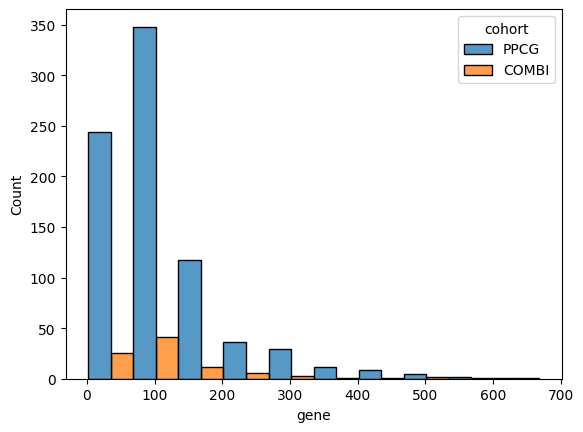

generating mutation matrix

896 patients
201 genes
          metastatic  ABCA13  ABCC4  ACP3  ACTA2  ADGRB3
patient                                                 
PPCG0001           0       0      0     0      0       0
PPCG0002           0       0      0     0      0       0
PPCG0003           0       0      0     0      0       0
PPCG0004           0       0      0     0      0       0
PPCG0005           0       1      0     0      0       0
evaluating enrichment

significant
False    199
True       1
Name: count, dtype: int64


,gene,n_mutated_meta,n_mutated_nonmeta,odds_ratio,p_value,q_value,significant,log_odds_ratio_logit,p_value_logit,q_value_logit,sig_fish,sig_logit
0,CTNNA2,11,28,3.713,0.001,0.080,False,1.223,0.002,0.146,False,False
2,PDE1C,8,26,2.813,0.019,0.460,False,0.956,0.025,0.706,False,False
3,ETV1,8,26,2.813,0.019,0.460,False,1.022,0.015,0.609,False,False
4,PRKG1,9,31,2.668,0.028,0.460,False,0.878,0.030,0.749,False,False
5,ADGRV1,8,28,2.605,0.026,0.460,False,0.824,0.057,0.784,False,False
6,NLGN1,9,32,2.581,0.030,0.460,False,0.854,0.034,0.749,False,False
7,ZBTB20,7,25,2.533,0.040,0.545,False,0.818,0.070,0.784,False,False
8,PPIP5K2,7,26,2.432,0.071,0.548,False,0.761,0.092,0.784,False,False
9,SORCS3,7,26,2.432,0.071,0.548,False,0.748,0.101,0.804,False,False
10,PSD3,8,30,2.425,0.049,0.548,False,0.755,0.078,0.784,False,False


In [ ]:
OUTDIR = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/downstream/genes'
LABEL = 'all_ppcg.all_combi.seeding'
outfile = f"{OUTDIR}/{LABEL}.tsv"

print('loading mutations')
table = load_data(INFILE_MUTATIONS, INFILE_SHEET)

print('filtering PPCG donors/mutations')
df_ppcg = table[table['cohort']=='PPCG'].copy()
# df_ppcg = filter_ppcg_control(df_ppcg)

print('filtering COMBI donors/mutations')
df_combi = table[table['cohort']=='COMBI'].copy()
# df_combi = filter_donors_without_prostate(df_combi)
# df_combi = filter_donors_without_dpclust(df_combi)
# df_combi = filter_donors_without_trees(df_combi)
df_combi = filter_seeding_trajectory(df_combi, verbose=True)
# df_combi = filter_primary_leaves(df_combi, verbose=True)

table = pd.concat([df_ppcg, df_combi], ignore_index=True)
table = filter_hypermutators(table, max_mutated_genes=500)
summarise_basic_info(table, treat='COMBI', control='PPCG')
summarise_vclasses(table, treat='COMBI', control='PPCG')
summarise_donors(table, treat='COMBI', control='PPCG')
plot_distribution(table, treat='COMBI', control='PPCG')

print('generating mutation matrix')
mat = gen_gene_matrix(table, top=200)

print('evaluating enrichment')
res = run_gene_enrichment(mat)
res.to_csv(outfile, sep='\t', index=False, float_format='%.3f')
res.head(10)


sub_ppcg.sub_combi.seeding

loading mutations
filtering PPCG donors/mutations
filtering COMBI donors/mutations

Remove primary/secondary leaf clones
11376 (removed 16090 mutations)

--- Basic Info ---

Treatment group: COMBI
Control group:   PPCG

       Donors  Genes  Variants
COMBI      62   5619      8356
PPCG       58   5583      8455

--- Variant Class ---

[COMBI]
       vars  genes  donors  med. vars p/donor
CNA     598    473      27                  7
INDEL   323    301      51                  5
SNV    3819   3116      62                 50
SV     3616   2687      60                 48

[PPCG]
       vars  genes  donors  med. vars p/donor
CNA    2105   1521      37                 16
INDEL   232    221      49                  4
SNV    3103   2611      58                 56
SV     3015   2207      57                 46

--- Donors ---

[COMBI]
vclass    CNA  INDEL  SNV   SV  total
donor                                
PPCG1076    2     22  205  350    569
PPCG0086    1     22  140  352    501
PPCG0996  

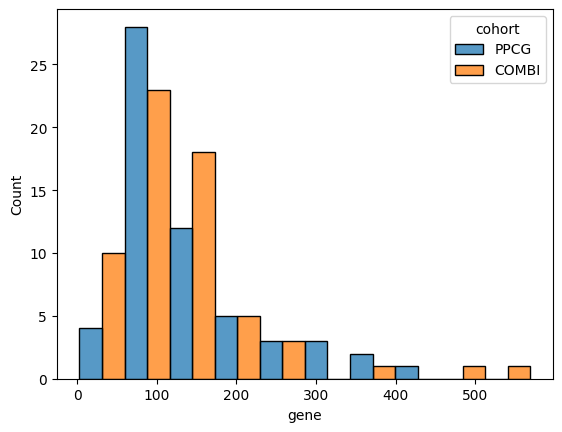

generating mutation matrix

120 patients
201 genes
          metastatic  ABCC4  ADGRB3  ADGRV1  AFDN  AGBL4
patient                                                 
PPCG0001           0      0       0       0     0      0
PPCG0003           0      0       0       0     1      0
PPCG0004           0      0       0       0     0      0
PPCG0006           0      0       0       0     0      0
PPCG0008           0      0       0       0     0      0
evaluating enrichment

significant
False    200
Name: count, dtype: int64


,gene,n_mutated_meta,n_mutated_nonmeta,odds_ratio,p_value,q_value,significant,log_odds_ratio_logit,p_value_logit,q_value_logit,sig_fish,sig_logit
0,DYM,7,0,inf,0.013,0.409,False,NaN,NaN,NaN,False,False
1,ETV1,8,0,inf,0.006,0.353,False,NaN,NaN,NaN,False,False
2,FAT3,6,0,inf,0.028,0.613,False,28.019,1.000,1.000,False,False
3,CYP7B1,6,0,inf,0.028,0.613,False,28.289,1.000,1.000,False,False
4,RBFOX1,7,1,7.255,0.062,0.892,False,2.251,0.045,0.876,False,False
5,SETBP1,7,1,7.255,0.062,0.892,False,2.190,0.049,0.876,False,False
6,ASTN2,6,1,6.107,0.115,1.000,False,2.092,0.066,0.876,False,False
7,ESRRG,6,1,6.107,0.115,1.000,False,1.854,0.092,0.876,False,False
8,NKAIN3,10,2,5.385,0.031,0.613,False,2.239,0.013,0.876,False,False
9,EDEM1,5,1,5.000,0.208,1.000,False,1.630,0.143,0.876,False,False


In [ ]:
OUTDIR = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/downstream/genes'
LABEL = 'sub_ppcg.sub_combi.seeding'
outfile = f"{OUTDIR}/{LABEL}.tsv"

print('loading mutations')
table = load_data(INFILE_MUTATIONS, INFILE_SHEET)

print('filtering PPCG donors/mutations')
df_ppcg = table[table['cohort']=='PPCG'].copy()
df_ppcg = filter_ppcg_control(df_ppcg)

print('filtering COMBI donors/mutations')
df_combi = table[table['cohort']=='COMBI'].copy()
df_combi = filter_donors_without_prostate(df_combi)
df_combi = filter_donors_without_dpclust(df_combi)
df_combi = filter_donors_without_trees(df_combi)
df_combi = filter_seeding_trajectory(df_combi, verbose=True)
# df_combi = filter_primary_leaves(df_combi, verbose=True)

table = pd.concat([df_ppcg, df_combi], ignore_index=True)
table = filter_hypermutators(table, max_mutated_genes=500)
summarise_basic_info(table, treat='COMBI', control='PPCG')
summarise_vclasses(table, treat='COMBI', control='PPCG')
summarise_donors(table, treat='COMBI', control='PPCG')
plot_distribution(table, treat='COMBI', control='PPCG')

print('generating mutation matrix')
mat = gen_gene_matrix(table, top=200)

print('evaluating enrichment')
res = run_gene_enrichment(mat)
res.to_csv(outfile, sep='\t', index=False, float_format='%.3f')
res.head(10)


---
## Genesets
---

In [ ]:
def gen_geneset_matrix(
    table: pd.DataFrame, 
    gsets_path: str, 
    max_genes: int|None=None, 
    top_combi: int|None=None,
    min_donors_prop: float|None=None, 
    min_combi_prop: float|None=None
    ) -> pd.DataFrame:
    gframe = pd.read_csv(gsets_path, sep='\t', header=0)
    all_genesets = sorted(list(set(gframe['geneset'].unique())))

    # removing TP53 because its a nightmare
    gframe = gframe[gframe['gene']!='TP53'].copy()
    table = table[table['gene']!='TP53'].copy()
    
    # filter genesets which are too big
    if max_genes is not None:
        counts = gframe['geneset'].value_counts()
        all_genesets = sorted(counts[counts<=max_genes].index.to_list())

    # init dataframe
    donor2genes = table.groupby('donor')['gene'].agg(set).to_dict()
    df = pd.DataFrame(index=all_genesets)
    for donor, genes in donor2genes.items():
        present = set(gframe[gframe['gene'].isin(genes)]['geneset'].unique())
        df[donor] = {gset: 1 if gset in present else 0 for gset in all_genesets}
    df = df.T

    # filter genesets with low mutation rate in CombiMets
    if min_combi_prop is not None:
        n_donors = table[table['cohort']=='COMBI']['donor'].nunique()
        thresh = int(min_combi_prop*n_donors)
        vcounts = df.sum()
        all_genesets = sorted(vcounts[vcounts>=thresh].index.to_list())
        df = df[all_genesets].copy()

    # filter genesets with low mutation rate in general
    if min_donors_prop is not None:
        n_donors = table['donor'].nunique()
        thresh = int(min_donors_prop*n_donors)
        vcounts = df.sum()
        all_genesets = sorted(vcounts[vcounts>=thresh].index.to_list())
        df = df[all_genesets].copy()
    
    # retain most commonly mutated genesets only
    if top_combi is not None:
        donors = sorted(list(table[table['cohort']=='COMBI']['donor'].unique()))
        vcounts = df.loc[donors].sum().sort_values(ascending=False)
        all_genesets = sorted(vcounts.head(top_combi).index.to_list())
        df = df[all_genesets].copy()

    donor2cohort = table.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
    df['metastatic'] = donor2cohort
    df['metastatic'] = df['metastatic'].map({'COMBI': 1, 'PPCG': 0})
    df['metastatic'] = df['metastatic'].astype(int)
    assert df['metastatic'].isna().sum() == 0
    df = df[['metastatic']+[x for x in df.columns if x!='metastatic']].copy()

    print()
    print(f"{df.shape[1]} genesets")
    print(f"{df.shape[0]} patients")
    print(f"{df['metastatic'].sum()} metastatic")
    print(df.iloc[:5, :3])
    return df

# test run
df = pd.read_csv(INFILE_MUTATIONS, sep='\t', header=0)
df['donor'] = df['sample'].apply(lambda x: x[:8])
df = df[df['cohort']=='COMBI'].copy()
mat = gen_geneset_matrix(df, gsets_path=INFILE_GENESETS, max_genes=50, min_donors_prop=0.25)


,gene,n_mutated_meta,n_mutated_nonmeta,odds_ratio,p_value,q_value,significant,log_odds_ratio_logit,p_value_logit,q_value_logit,sig_fish,sig_logit
0,CTNNA2,11,28,3.713,0.001,0.080,False,1.223,0.002,0.146,False,False
2,PDE1C,8,26,2.813,0.019,0.460,False,0.956,0.025,0.706,False,False
3,ETV1,8,26,2.813,0.019,0.460,False,1.022,0.015,0.609,False,False
4,PRKG1,9,31,2.668,0.028,0.460,False,0.878,0.030,0.749,False,False
5,ADGRV1,8,28,2.605,0.026,0.460,False,0.824,0.057,0.784,False,False


In [454]:
res.sort_values('p_value').head(10)

,gene,n_mutated_meta,n_mutated_nonmeta,odds_ratio,p_value,q_value,significant,log_odds_ratio_logit,p_value_logit,q_value_logit,sig_fish,sig_logit
48,GOBP_RESPONSE_TO_LEPTIN,13,0,inf,0.000,0.429,False,25.194,1.000,1.000,False,False
357,GOBP_INDOLE_CONTAINING_COMPOUND_METABOLIC_PROCESS,30,10,5.143,0.000,0.429,False,1.479,0.001,1.000,False,False
372,GOBP_ENDOCHONDRAL_BONE_MORPHOGENESIS,33,13,4.569,0.000,0.429,False,1.290,0.003,1.000,False,False
364,GOBP_POSITIVE_REGULATION_OF_BMP_SIGNALING_PATHWAY,28,9,5.081,0.000,0.429,False,1.360,0.004,1.000,False,False
359,GOBP_BLOOD_VESSEL_REMODELING,24,7,5.143,0.001,0.577,False,1.376,0.006,1.000,False,False
478,GOBP_NEPHRON_MORPHOGENESIS,42,23,3.995,0.001,0.577,False,1.095,0.013,1.000,False,False
268,GOBP_RESPONSE_TO_IRON_ION,17,3,7.602,0.001,0.577,False,1.823,0.007,1.000,False,False
398,GOBP_LABYRINTHINE_LAYER_DEVELOPMENT,26,9,4.424,0.001,0.577,False,1.188,0.013,1.000,False,False
365,GOBP_MITOCHONDRIAL_DEPOLARIZATION,23,7,4.788,0.001,0.577,False,1.254,0.015,1.000,False,False
537,GOBP_REGULATION_OF_PROTEIN_MATURATION,33,15,3.784,0.001,0.577,False,1.001,0.036,1.000,False,False


In [385]:
query = 'HALLMARK_UV_RESPONSE_DN'
gframe = pd.read_csv(INFILE_GENESETS, sep='\t', header=0) 
genelist = sorted(list(gframe[gframe['geneset']==query]['gene'].unique()))
muts = table[table['gene'].isin(genelist)]
print(muts.groupby('cohort')['donor'].nunique())

counts = pd.DataFrame(index=genelist)
counts['COMBI'] = muts[muts['cohort']=='COMBI'].groupby('gene')['donor'].nunique()
counts['PPCG'] = muts[muts['cohort']=='PPCG'].groupby('gene')['donor'].nunique()
counts = counts.fillna(0).astype(int)
counts

cohort
COMBI    65
PPCG     55
Name: donor, dtype: int64


,COMBI,PPCG
ABCC1,3,1
ACVR2A,6,0
ADD3,2,1
ADGRL2,4,4
ADORA2B,1,2
AGGF1,0,2
AKT3,4,2
AMPH,1,2
ANXA2,1,0
ANXA4,3,0


In [ ]:
print(res['significant'].value_counts())
res[res['significant']==True]

significant
False    899
True      32
Name: count, dtype: int64


,gene,n_mutated_meta,n_mutated_nonmeta,odds_ratio,p_value,q_value,significant,log_odds_ratio,sig_fish,sig_logit
0,NLGN1,14,38,6.075,0.000,0.001,True,1.827,True,True
1,NTRK3,12,35,5.460,0.000,0.005,True,1.693,True,True
2,AHNAK2,22,77,5.329,0.000,0.000,True,1.823,True,True
3,ZBTB20,12,37,5.152,0.000,0.006,True,1.660,True,True
4,MIPOL1,12,40,4.749,0.000,0.006,True,1.542,True,True
5,PSD3,12,40,4.749,0.000,0.006,True,1.580,True,True
6,SGCZ,14,49,4.650,0.000,0.005,True,1.533,True,True
7,TP53,22,89,4.541,0.000,0.000,True,1.511,True,True
8,PTCHD4,12,42,4.512,0.000,0.008,True,1.518,True,True
9,MACROD2,19,79,4.183,0.000,0.002,True,1.427,True,True


<br><br><br><br><br><br><br><br><br><br><br><br>

In [ ]:
def evaluate(df: pd.DataFrame, treat: str, control: str, genelist: list[str]) -> pd.DataFrame:
    data = []
    for gene in genelist:
        counts = df.groupby('cohort')[gene].sum()
        fish_pval = _calc_fisher(df, treat, control, gene)
        logit_pval, converged = _calc_logit(df, gene)
        data.append((gene, counts[treat], counts[control], fish_pval, logit_pval, converged))

    rframe = pd.DataFrame.from_records(data, columns=['geneset', 'posclass donors', 'negclass donors', 'fisher_pval', 'logit_pval', 'logit_converged'])
    rframe = rframe.sort_values('fisher_pval')
    return rframe

def _calc_fisher(df: pd.DataFrame, treat: str, control: str, gene: str) -> float:
    a = ((df[gene]==1) & (df['cohort']==treat)).sum()
    b = ((df[gene]==1) & (df['cohort']==control)).sum()
    c = ((df[gene]==0) & (df['cohort']==treat)).sum()
    d = ((df[gene]==0) & (df['cohort']==control)).sum()
    res = stats.fisher_exact([[a, b], [c, d]], alternative='two-sided')
    return float(res.pvalue)  # type: ignore

def _calc_logit(df: pd.DataFrame, gene: str):
    y = df[gene]
    X = pd.DataFrame({
        "cohort": (df["cohort"] == "positive").astype(int),
        "log_TMB": np.log1p(df["TMB"]) # log(1 + TMB)
    })
    X = sm.add_constant(X)
    try:
        model = sm.Logit(y, X).fit(disp=0)
        return float(model.pvalues['cohort']), model.mle_retvals['converged']
    except LinAlgError:
        return 1.0, False

res = evaluate(mat, treat='COMBI', control='PPCG', genelist=sorted(list(DRIVERS)))
res['fisher_pval_adj'] = multipletests(res['fisher_pval'], method='fdr_bh')[1]
res.head(10)